In [1]:
import sys
sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import bayesflow as bf
import keras
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


In [2]:
parent_dir = os.path.dirname(os.getcwd())
print(f'parent_dir: {parent_dir}', flush=True)

# Spearman-Brown Correction

def spearman(r, k=2):
    return (k*r)/(1+r)


parent_dir: /home/administrator/Documents/amortized-dmc


# Read Reliability Data

In [3]:
lst_files = os.listdir(parent_dir + '/data/reliability')

lst_data = []

for path in lst_files:
    lst_data.append(pd.read_csv(parent_dir + '/data/reliability/' + path))

data = pd.concat(lst_data)

# Spearman-Brown Correction

In [4]:
param_names = ('A', 'tau', 'mu_c', 'mu_r', 'sd_r', 'b')

In [5]:
for par in param_names:
    data[par + '_c'] = spearman(data[par])

In [6]:
# Exclude wide spacing condition
data = data[data['spacing'] != 'wide']

In [7]:
# create variables that indicate network and prior condition:

data = data.copy()

data['sdr'] = '$sd_r$ fixed'
data['priors'] = 'updated'

data.loc[data['network_name'].str.contains('estimated', na=False), 'sdr'] = '$sd_r$ estimated'
data.loc[data['network_name'].str.contains('winsim', na=False), 'priors'] = 'initial'
data.loc[data['network_name'].str.contains('initial', na=False), 'priors'] = 'initial'

data['category'] = data['sdr'] + ', ' + data['priors'] + ' priors'

In [8]:
# Rename Data sets

data['data_set'] = data['data_set'].str.replace('model_data_hedge_', '', regex=False)
data['data_set'] = data['data_set'].str.replace('hedge', 'Hedge ', regex=False)
data['data_set'] = data['data_set'].str.replace('whitehead', 'Whitehead ', regex=False)
data['data_set'] = data['data_set'].str.replace('empirical_study', 'Present Study', regex=False)

# Hedge 3 and 4 include Speed-Accuracy Manipulation -> exlude them
data = data[~data['data_set'].isin(['Hedge 3', 'Hedge 4'])]

# rename data sets
data['data_set'] = data['data_set'].str.replace('Hedge 3', 'Hedge 3 - ACC', regex=False)
data['data_set'] = data['data_set'].str.replace('Hedge 4', 'Hedge 3 - Speed', regex=False)
data['data_set'] = data['data_set'].str.replace('Hedge 5', 'Hedge 3', regex=False)

In [9]:

custom_order = ['Hedge 1', 'Hedge 2',  'Hedge 3', 'Whitehead 1', 'Whitehead 2', 'Whitehead 3', 'Present Study']

data['data_set'] = pd.Categorical(data['data_set'], categories=custom_order, ordered=True)

data = data.sort_values('data_set')


# Number of trials per data set

In [10]:
#rows = []

#data_sets = ['model_data_hedge_hedge1', 'model_data_hedge_hedge2', 'model_data_hedge_hedge5', 'model_data_hedge_whitehead1', 'model_data_hedge_whitehead2', 'model_data_hedge_whitehead3']


#for path in data_sets:
#    data_single = pd.read_csv(parent_dir + '/data_complete/acdc/' + path + '.csv')

#    mean_num_trials = np.mean(data_single.groupby('participant').count())
#    num_trials = round(mean_num_trials / 2)

#    data_set_name = path.replace('model_data_hedge_', '')
#    data_set_name = data_set_name.replace('hedge', 'Hedge ')
#    data_set_name = data_set_name.replace('whitehead', 'Whitehead ')
#    data_set_name = data_set_name.replace('Hedge 5', 'Hedge 3')

#    rows.append({
#        'data_set': data_set_name,
#        'trial_num': num_trials
#    })

#rows.append({
#    'data_set': 'Present Study',
#    'trial_num': 330
#})

#data_trial_number = pd.DataFrame(rows)
#data_trial_number.to_csv('../data/reliability_trial_nums.csv')

In [11]:
data_trial_number = pd.read_csv('../data/reliability_trial_nums.csv')

In [12]:
data_set_names = data_trial_number['data_set'].unique()

In [13]:
# add trial number to data set
data = pd.merge(data, data_trial_number, how='left', on='data_set')
data['trial_num'] = data['trial_num'].astype(int).astype(str)
data['data_set_name'] = data['data_set'] + ' (' + data['trial_num'] +')'

/tmp/ipykernel_56577/1972531765.py:51: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


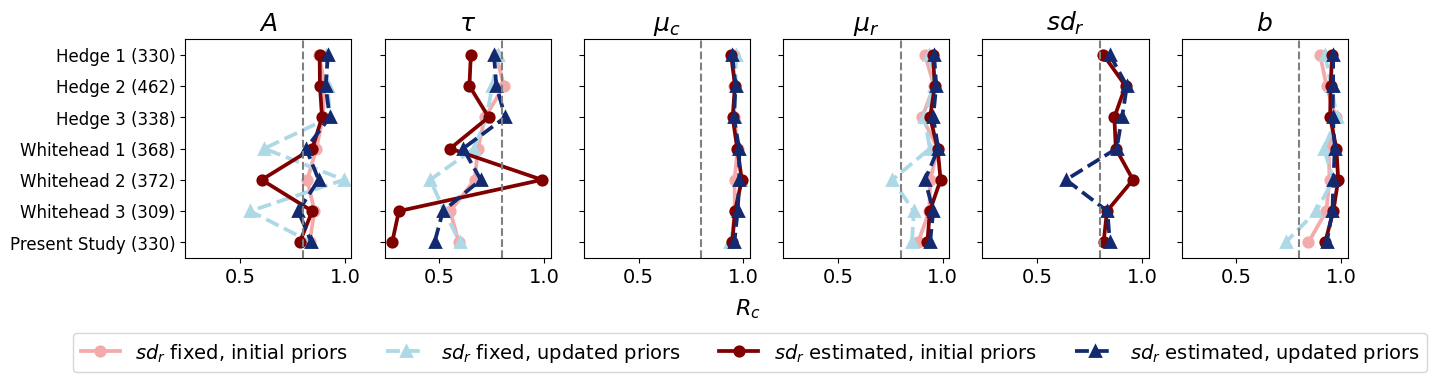

In [14]:
fontsize = 14

custom_palette = {
    '$sd_r$ fixed, updated priors': "#add8e6",
    '$sd_r$ estimated, updated priors': "#132a70",
    '$sd_r$ fixed, initial priors': "#f4aaaa",
    '$sd_r$ estimated, initial priors': 'maroon'
}

hue_order = [
    '$sd_r$ fixed, initial priors',
    '$sd_r$ fixed, updated priors',
    '$sd_r$ estimated, initial priors',
    '$sd_r$ estimated, updated priors'
]

fig, axes = plt.subplots(1,6, figsize = (15,3), sharex=True)

for p, ax in zip(param_names, axes):

    if p == 'sd_r':
        data_plot = data[~np.isnan(data['sd_r_c'])]
    else:
        data_plot = data
        
    sns.pointplot(data=data_plot, x=p + '_c', y = 'data_set_name', hue = 'category', linestyles=['-', '--', '-', '--'], markers=['o','^', 'o', '^'],  palette=custom_palette, ax=ax, hue_order=hue_order)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.legend(title = '')

    if p != 'A':
        ax.set_yticklabels([])

    suff = "$\\" if p in ["tau", "mu_c", "mu_r"] else "$"

    label = suff + p + "$"

    ax.set_title(label, fontsize=fontsize+4)
    ax.axvline(x=0.8, color='gray', linestyle='--') 

    if p != 'b':
        ax.legend_.remove()
    else:
        ax.legend(loc='upper center', bbox_to_anchor=(-2.6, -0.3), ncol=4, fontsize=fontsize)

    ax.tick_params(axis='x', labelsize=fontsize )  
    ax.tick_params(axis='y', labelsize=fontsize - 2)

fig.supxlabel('$R_c$', fontsize=fontsize+2, y=-0.06)
fig.tight_layout()
fig.subplots_adjust(bottom=0.15)

# save plot
#plt.savefig(parent_dir + '/plots/plots_reliability/reliability_A_multiple_datasets.png', dpi=300, bbox_inches='tight')